<a href="https://colab.research.google.com/github/Chuuya1124/APM1220_FA5_PCA/blob/main/APM1220_FA5_Awit%2C_Julia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# APM1220 – Formative Assessment 5: Principal Component Analysis


## Setup and loading the data


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.width", 200)

import os
FILE = "world-happiness-report-2021.csv"
if not os.path.exists(FILE):
    from google.colab import files
    uploaded = files.upload()
    FILE = list(uploaded.keys())[0]

raw = pd.read_csv(FILE)
print("Full dataset shape:", raw.shape)
raw.head()

Full dataset shape: (149, 20)


,Country name,Regional indicator,Ladder score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.842,0.032,7.904,7.780,10.775,0.954,72.000,0.949,-0.098,0.186,2.430,1.446,1.106,0.741,0.691,0.124,0.481,3.253
1,Denmark,Western Europe,7.620,0.035,7.687,7.552,10.933,0.954,72.700,0.946,0.030,0.179,2.430,1.502,1.108,0.763,0.686,0.208,0.485,2.868
2,Switzerland,Western Europe,7.571,0.036,7.643,7.500,11.117,0.942,74.400,0.919,0.025,0.292,2.430,1.566,1.079,0.816,0.653,0.204,0.413,2.839
3,Iceland,Western Europe,7.554,0.059,7.670,7.438,10.878,0.983,73.000,0.955,0.160,0.673,2.430,1.482,1.172,0.772,0.698,0.293,0.170,2.967
4,Netherlands,Western Europe,7.464,0.027,7.518,7.410,10.932,0.942,72.400,0.913,0.175,0.338,2.430,1.501,1.079,0.753,0.647,0.302,0.384,2.798


# Part A: Data Preparation and Descriptive Analysis

### A1: Observations and variables

In [3]:
# Map the seven required variables (robust to small column-name differences)
wanted = {
    "Ladder Score": "Ladder score",
    "Logged GDP per capita": "Logged GDP per capita",
    "Social Support": "Social support",
    "Healthy Life Expectancy": "Healthy life expectancy",
    "Freedom to Make Life Choices": "Freedom to make life choices",
    "Generosity": "Generosity",
    "Perceptions of Corruption": "Perceptions of corruption",
}
lower = {c.lower().strip(): c for c in raw.columns}
cols = [lower[v.lower()] for v in wanted.values()]

country_col = lower["country name"]
data = raw[cols].copy()
data.columns = list(wanted.keys())
countries = raw[country_col]

n_obs, n_vars = data.shape
print(f"Number of observations (countries): {n_obs}")
print(f"Number of variables: {n_vars}")
print("Variables:", list(data.columns))
print("Missing values per variable:\n", data.isna().sum())

Number of observations (countries): 149
Number of variables: 7
Variables: ['Ladder Score', 'Logged GDP per capita', 'Social Support', 'Healthy Life Expectancy', 'Freedom to Make Life Choices', 'Generosity', 'Perceptions of Corruption']
Missing values per variable:
 Ladder Score                    0
Logged GDP per capita           0
Social Support                  0
Healthy Life Expectancy         0
Freedom to Make Life Choices    0
Generosity                      0
Perceptions of Corruption       0
dtype: int64


**Answer A1:** The analysis uses one observation per country and the seven quantitative variables listed above. Country name and regional indicator are **excluded** from the PCA (country names are used only to label plots).  
**Result: n = 149 countries and p = 7 variables, with no missing values.**

### A2: Mean and standard deviation

In [4]:
desc = pd.DataFrame({"Mean": data.mean(), "Std. Dev.": data.std(ddof=1)})
desc

,Mean,Std. Dev.
Ladder Score,5.533,1.074
Logged GDP per capita,9.432,1.159
Social Support,0.815,0.115
Healthy Life Expectancy,64.993,6.762
Freedom to Make Life Choices,0.792,0.113
Generosity,-0.015,0.151
Perceptions of Corruption,0.727,0.179


**Answer A2:** Mean (SD): Ladder score 5.533 (1.074); Logged GDP per capita 9.432 (1.159); Social support 0.815 (0.115); Healthy life expectancy 64.993 (6.762); Freedom 0.792 (0.113); Generosity -0.015 (0.151); Perceptions of corruption 0.727 (0.179).

### A3: Why standardize before PCA?
The seven variables are measured on different scales and units: the ladder score is on a 0–10 scale, logged GDP per capita is roughly 6.5–11.5, healthy life expectancy is in years (roughly 48–77), while social support, freedom, and corruption are proportions between 0 and 1, and generosity is a small residual centred near 0.
PCA looks for directions of **maximum variance**. Without standardization, variables with large numeric variance (e.g., life expectancy in years) would dominate the first component simply because of their units, not because they are more important. Standardizing (mean 0, variance 1) gives every variable equal weight, and PCA on standardized data is equivalent to PCA on the **correlation matrix**, which is what this assessment requires.

### A4: Correlation matrix

,Ladder Score,Logged GDP per capita,Social Support,Healthy Life Expectancy,Freedom to Make Life Choices,Generosity,Perceptions of Corruption
Ladder Score,1.000,0.790,0.757,0.768,0.608,-0.018,-0.421
Logged GDP per capita,0.790,1.000,0.785,0.859,0.432,-0.199,-0.342
Social Support,0.757,0.785,1.000,0.723,0.483,-0.115,-0.203
Healthy Life Expectancy,0.768,0.859,0.723,1.000,0.461,-0.162,-0.364
Freedom to Make Life Choices,0.608,0.432,0.483,0.461,1.000,0.169,-0.401
Generosity,-0.018,-0.199,-0.115,-0.162,0.169,1.000,-0.164
Perceptions of Corruption,-0.421,-0.342,-0.203,-0.364,-0.401,-0.164,1.000


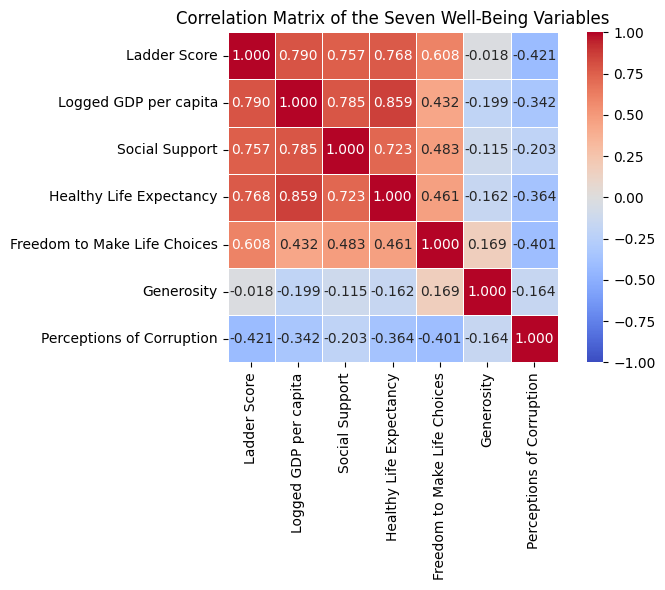

Top 5 strongest pairs:


,Variable 1,Variable 2,r
0,Logged GDP per capita,Healthy Life Expectancy,0.859
1,Ladder Score,Logged GDP per capita,0.790
2,Logged GDP per capita,Social Support,0.785
3,Ladder Score,Healthy Life Expectancy,0.768
4,Ladder Score,Social Support,0.757


In [5]:
corr = data.corr()
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=.5)
plt.title("Correlation Matrix of the Seven Well-Being Variables")
plt.tight_layout(); plt.show()

# Strongest pairs (by absolute correlation)
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().rename("r").reset_index())
pairs.columns = ["Variable 1", "Variable 2", "r"]
pairs = pairs.reindex(pairs["r"].abs().sort_values(ascending=False).index).reset_index(drop=True)
print("Top 5 strongest pairs:")
display(pairs.head(5))

**Answer A4:** The strongest relationships are Logged GDP per capita and Healthy life expectancy (r = 0.859), Ladder score and Logged GDP per capita (r = 0.790), Logged GDP per capita and Social support (r = 0.785), and Ladder score with Healthy life expectancy (0.768) and Social support (0.757), all strongly positive. Perceptions of corruption is negatively related to the others (e.g., with Ladder score, r = -0.421), and Generosity is almost uncorrelated with them (e.g., with Ladder score, r = -0.018). These strong correlations are exactly the redundancy that PCA can exploit for data reduction.

# Part B: Principal Component Analysis

### B1: Standardize and run PCA on the correlation matrix

In [6]:
# Standardize: z = (x - mean) / sd
scaler = StandardScaler()
Z = scaler.fit_transform(data)
Z_df = pd.DataFrame(Z, columns=data.columns)
print("Means of standardized data (≈0):", np.round(Z_df.mean().values, 3))
print("Std devs of standardized data (≈1):", np.round(Z_df.std(ddof=0).values, 3))

# PCA = eigen-decomposition of the correlation matrix
R = np.corrcoef(Z, rowvar=False)                    # equals data.corr()
eigvals, eigvecs = np.linalg.eigh(R)
order = np.argsort(eigvals)[::-1]                   # sort descending
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

# Make the largest |coefficient| of each PC positive (signs are arbitrary)
for j in range(eigvecs.shape[1]):
    if eigvecs[np.argmax(np.abs(eigvecs[:, j])), j] < 0:
        eigvecs[:, j] *= -1

pc_names = [f"PC{i+1}" for i in range(n_vars)]
print("Check: sum of eigenvalues =", round(eigvals.sum(), 3), "(equals number of variables =", n_vars, ")")

# Cross-check with scikit-learn
skl = PCA().fit(Z)
print("sklearn variance ratios match eigen-decomposition:",
      np.allclose(skl.explained_variance_ratio_, eigvals / eigvals.sum()))

Means of standardized data (≈0): [-0. -0.  0.  0. -0. -0. -0.]
Std devs of standardized data (≈1): [1. 1. 1. 1. 1. 1. 1.]
Check: sum of eigenvalues = 7.0 (equals number of variables = 7 )
sklearn variance ratios match eigen-decomposition: True


### B2–B4: Eigenvalues, proportion of variance, cumulative proportion

In [7]:
prop = eigvals / eigvals.sum()          # lambda_k / p
cum = np.cumsum(prop)
summary = pd.DataFrame({"Eigenvalue": eigvals,
                        "Proportion of Variance": prop,
                        "Cumulative Proportion": cum}, index=pc_names)
summary

,Eigenvalue,Proportion of Variance,Cumulative Proportion
PC1,3.914,0.559,0.559
PC2,1.289,0.184,0.743
PC3,0.708,0.101,0.844
PC4,0.518,0.074,0.918
PC5,0.251,0.036,0.954
PC6,0.193,0.028,0.982
PC7,0.126,0.018,1.000


**Reading the table.** Each eigenvalue λₖ is the variance captured by component *k*. Because the variables are standardized, the total variance is 7, so the proportion of variance explained by component *k* is **λₖ / 7**. The cumulative column shows how much of the total information is retained as components are added.

### B5: Eigenvectors (component coefficients)

In [8]:
eig_df = pd.DataFrame(eigvecs, index=data.columns, columns=pc_names)
print("All eigenvectors (columns = PCs):")
display(eig_df)

# Decide how many components to retain
k_kaiser = int((eigvals > 1).sum())
print(f"\nComponents with eigenvalue > 1: {k_kaiser}")
print("Eigenvectors of the retained components:")
display(eig_df.iloc[:, :k_kaiser])

All eigenvectors (columns = PCs):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Ladder Score,0.464,0.040,0.088,-0.013,0.095,0.869,-0.105
Logged GDP per capita,0.459,-0.197,-0.002,-0.256,-0.174,-0.124,0.800
Social Support,0.433,-0.163,0.324,-0.087,0.704,-0.361,-0.218
Healthy Life Expectancy,0.453,-0.146,-0.032,-0.230,-0.612,-0.234,-0.539
Freedom to Make Life Choices,0.341,0.365,0.167,0.811,-0.163,-0.174,0.092
Generosity,-0.042,0.753,0.466,-0.449,-0.083,-0.051,0.041
Perceptions of Corruption,-0.252,-0.460,0.801,0.119,-0.238,0.107,0.037



Components with eigenvalue > 1: 2
Eigenvectors of the retained components:


,PC1,PC2
Ladder Score,0.464,0.040
Logged GDP per capita,0.459,-0.197
Social Support,0.433,-0.163
Healthy Life Expectancy,0.453,-0.146
Freedom to Make Life Choices,0.341,0.365
Generosity,-0.042,0.753
Perceptions of Corruption,-0.252,-0.460


### B6: Largest absolute coefficients in PC1

In [9]:
pc1 = eig_df["PC1"]
pc1_rank = pc1.reindex(pc1.abs().sort_values(ascending=False).index)
display(pc1_rank.to_frame("PC1 coefficient").assign(**{"|Coefficient|": pc1_rank.abs()}))
print("Largest |coefficients| in PC1:", ", ".join(pc1_rank.index[:3]))

,PC1 coefficient,|Coefficient|
Ladder Score,0.464,0.464
Logged GDP per capita,0.459,0.459
Healthy Life Expectancy,0.453,0.453
Social Support,0.433,0.433
Freedom to Make Life Choices,0.341,0.341
Perceptions of Corruption,-0.252,0.252
Generosity,-0.042,0.042


Largest |coefficients| in PC1: Ladder Score, Logged GDP per capita, Healthy Life Expectancy


# Part C: Determining the Number of Components

### C1–C2: Scree plot and the elbow

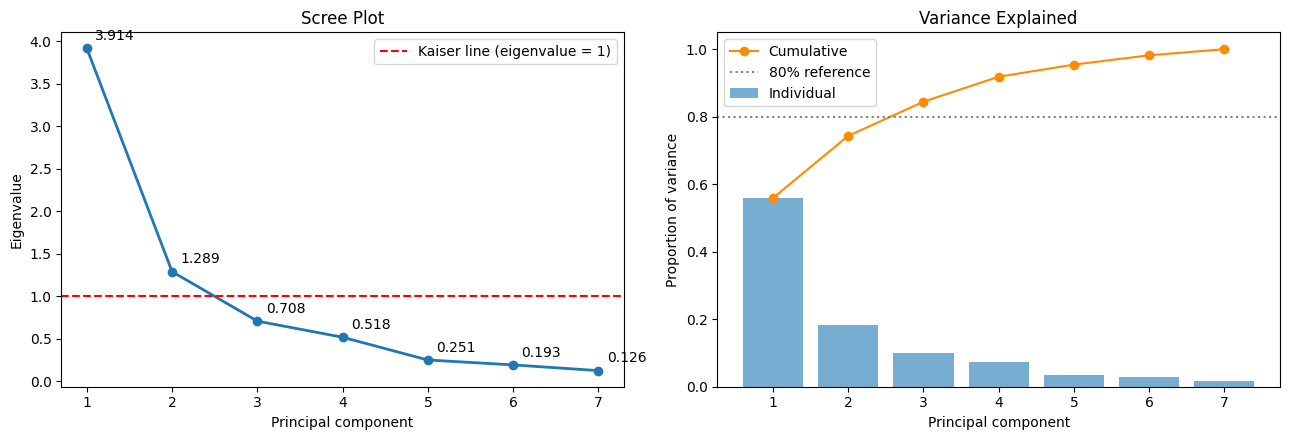

,Drop from previous PC
PC1→PC2,2.624
PC2→PC3,0.581
PC3→PC4,0.190
PC4→PC5,0.267
PC5→PC6,0.058
PC6→PC7,0.067


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].plot(range(1, n_vars+1), eigvals, "o-", lw=2)
ax[0].axhline(1, color="red", ls="--", label="Kaiser line (eigenvalue = 1)")
ax[0].set_xlabel("Principal component"); ax[0].set_ylabel("Eigenvalue")
ax[0].set_title("Scree Plot"); ax[0].set_xticks(range(1, n_vars+1)); ax[0].legend()
for i, v in enumerate(eigvals): ax[0].annotate(f"{v:.3f}", (i+1, v), textcoords="offset points", xytext=(6, 6))

ax[1].bar(range(1, n_vars+1), prop, alpha=.6, label="Individual")
ax[1].plot(range(1, n_vars+1), cum, "o-", color="darkorange", label="Cumulative")
ax[1].axhline(0.80, color="gray", ls=":", label="80% reference")
ax[1].set_xlabel("Principal component"); ax[1].set_ylabel("Proportion of variance")
ax[1].set_title("Variance Explained"); ax[1].set_xticks(range(1, n_vars+1)); ax[1].legend()
plt.tight_layout(); plt.show()

# Drops between successive eigenvalues help locate the elbow
drops = pd.DataFrame({"Drop from previous PC": -np.diff(eigvals)},
                     index=[f"PC{i}→PC{i+1}" for i in range(1, n_vars)])
display(drops)

**Answer C2 (elbow).** The eigenvalues are 3.914, 1.289, 0.708, 0.518, 0.251, 0.193, 0.126. The largest drop is PC1 to PC2 (2.624), then PC2 to PC3 (0.581), after which the curve flattens (drops of 0.190 or less except PC4 to PC5 at 0.267). The apparent elbow is at PC3, so the scree plot supports retaining the two components before it (PC1 and PC2).

### C3: Kaiser criterion

In [11]:
kaiser = summary[summary["Eigenvalue"] > 1]
print(f"Kaiser criterion retains {len(kaiser)} component(s):")
display(kaiser)

Kaiser criterion retains 2 component(s):


,Eigenvalue,Proportion of Variance,Cumulative Proportion
PC1,3.914,0.559,0.559
PC2,1.289,0.184,0.743


### C4: Decision on the number of components

In [12]:
k = k_kaiser
print(f"Retained components: {k}")
print(f"Cumulative variance explained by retained components: {cum[k-1]:.3f} ({cum[k-1]*100:.1f}%)")
print(f"Variance reduced from {n_vars} variables to {k} components.")

Retained components: 2
Cumulative variance explained by retained components: 0.743 (74.3%)
Variance reduced from 7 variables to 2 components.


**Answer C4:**

Retain 2 components: the scree elbow is at PC3 (so 2 components come before it), the Kaiser criterion keeps PC1 (3.914) and PC2 (1.289), and together they explain 74.3% of the total variance (PC3 would add only 10.1%, reaching 84.4%). Two components are also easy to interpret, so the 7 variables are reduced to 2.

### C5. Why not rely on only one criterion?
No single rule is definitive. The Kaiser criterion can keep too many components (or too few) depending on the number of variables and is a fairly arbitrary cutoff; the scree plot is subjective because different readers see different elbows; and cumulative variance depends on a chosen threshold (70%, 80%, 90%) that is a convention, not a law. Using all three, together with subject-matter interpretability (does each retained component mean something about well-being?), gives a more reliable and defensible decision.

# Part D: Interpretation of Principal Components

### D1–D2: Loadings, PC1 and PC2

Loadings (variable–component correlations):


,PC1,PC2
Ladder Score,0.918,0.045
Logged GDP per capita,0.908,-0.223
Social Support,0.856,-0.185
Healthy Life Expectancy,0.896,-0.166
Freedom to Make Life Choices,0.674,0.414
Generosity,-0.084,0.855
Perceptions of Corruption,-0.499,-0.522


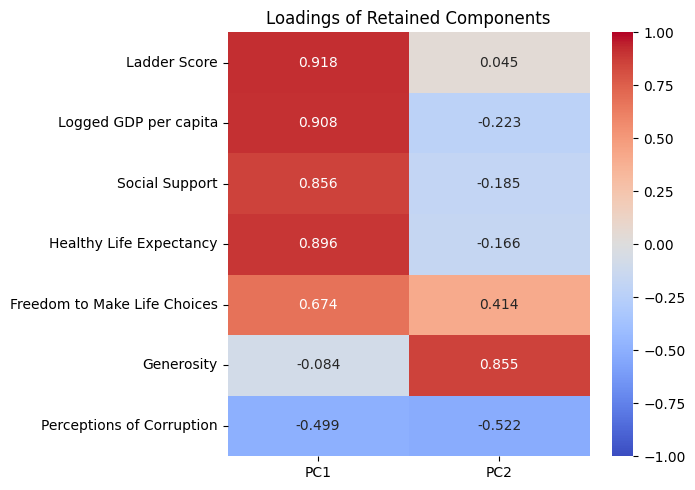


PC1  (eigenvalue 3.914, 55.9% of variance)
  Notable positive: Ladder Score (0.464), Logged GDP per capita (0.459), Healthy Life Expectancy (0.453), Social Support (0.433)
  Notable negative: none

PC2  (eigenvalue 1.289, 18.4% of variance)
  Notable positive: Generosity (0.753), Freedom to Make Life Choices (0.365)
  Notable negative: Perceptions of Corruption (-0.460)


In [13]:
# Loadings = eigenvector * sqrt(eigenvalue)
loadings = pd.DataFrame(eigvecs * np.sqrt(eigvals), index=data.columns, columns=pc_names)
print("Loadings (variable–component correlations):")
display(loadings.iloc[:, :max(k, 2)])

plt.figure(figsize=(7, 5))
sns.heatmap(loadings.iloc[:, :max(k, 2)], annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Loadings of Retained Components"); plt.tight_layout(); plt.show()

# Auto-generated reading of PC1 and PC2
for pc in ["PC1", "PC2"]:
    s = eig_df[pc]
    pos = s[s >= 0.35].sort_values(ascending=False)
    neg = s[s <= -0.35].sort_values()
    print(f"\n{pc}  (eigenvalue {eigvals[int(pc[2])-1]:.3f}, {prop[int(pc[2])-1]*100:.1f}% of variance)")
    print("  Notable positive:", ", ".join(f"{i} ({v:.3f})" for i, v in pos.items()) or "none")
    print("  Notable negative:", ", ".join(f"{i} ({v:.3f})" for i, v in neg.items()) or "none")

**PC1 (eigenvalue 3.914, 55.9% of variance).** Coefficients: Ladder score 0.464, Logged GDP 0.459, Healthy life expectancy 0.453, Social support 0.433, Freedom 0.341, Perceptions of corruption -0.252, Generosity -0.042. The first four variables are large and positive, so PC1 is essentially a weighted average of happiness, income, health and social support. Corruption enters negatively, so a high PC1 score means a country is happier, richer, healthier, more socially supported, freer and perceives less corruption (e.g., Finland, Denmark, Singapore); a low score means the opposite (e.g., Afghanistan, Burundi, Haiti). Generosity contributes almost nothing.

**PC2 (eigenvalue 1.289, 18.4% of variance).** Coefficients: Generosity 0.753, Perceptions of corruption -0.460, Freedom 0.365, Logged GDP -0.197, Social support -0.163, Healthy life expectancy -0.146, Ladder score 0.040. PC2 is mainly a generosity and civic-freedom versus corruption-perception contrast: countries with high PC2 are more generous, feel freer, and perceive less corruption, regardless of how wealthy they are (Ladder score is almost unrelated to PC2). It captures variation that PC1 does not.

### D3: Name for PC1

**Suggested label: "Overall Socio-Economic Well-Being (Prosperity & Social Quality) Index"**  

Justification: PC1 has large, same-signed coefficients on ladder score (0.464), GDP per capita (0.459), healthy life expectancy (0.453) and social support (0.433), with freedom positive (0.341) and corruption negative (-0.252), so it summarizes how prosperous, healthy, socially supported and well-governed a country is — and that axis also tracks self-reported life satisfaction. A single number per country therefore ranks general well-being.

### Visualizations: PC scores and biplot

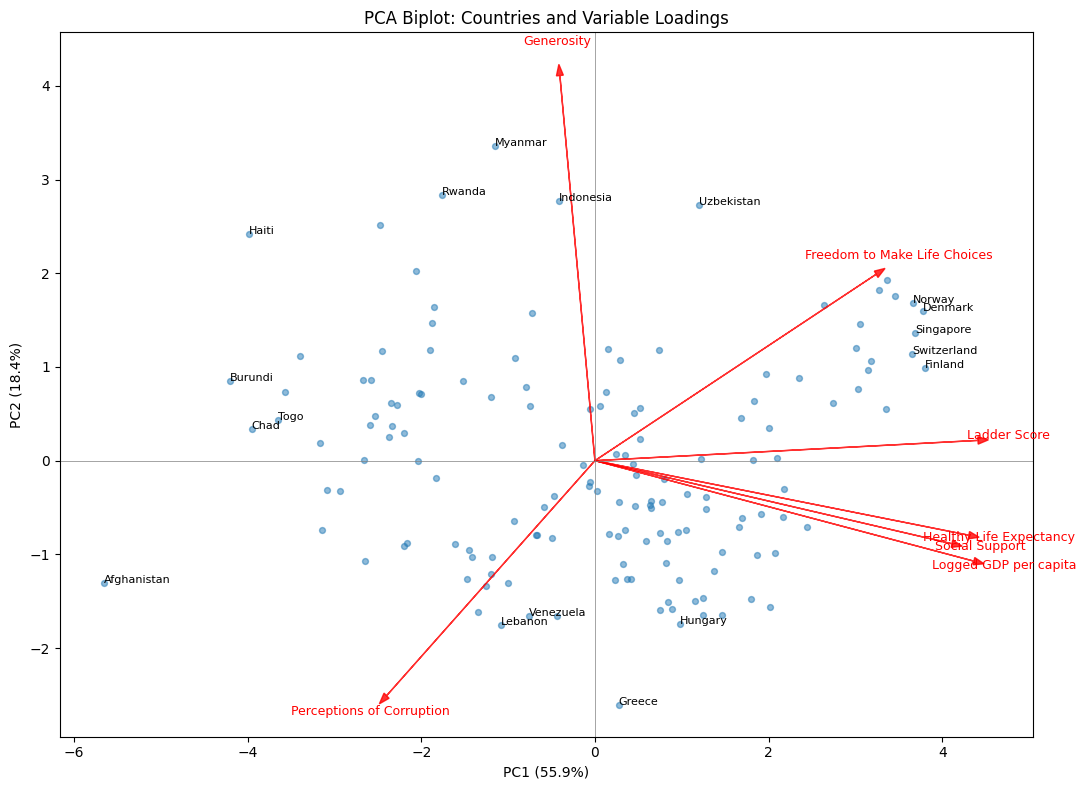

Top 5 countries on PC1: Finland, Denmark, Singapore, Norway, Switzerland
Bottom 5 countries on PC1: Afghanistan, Burundi, Haiti, Chad, Togo


In [14]:
scores = Z @ eigvecs[:, :2]
score_df = pd.DataFrame(scores, columns=["PC1", "PC2"]); score_df["Country"] = countries.values

fig, ax = plt.subplots(figsize=(11, 8))
ax.scatter(score_df["PC1"], score_df["PC2"], s=18, alpha=.5)
# label extreme countries
extreme = pd.concat([score_df.nlargest(5, "PC1"), score_df.nsmallest(5, "PC1"),
                     score_df.nlargest(4, "PC2"), score_df.nsmallest(4, "PC2")]).drop_duplicates("Country")
for _, r in extreme.iterrows(): ax.annotate(r["Country"], (r["PC1"], r["PC2"]), fontsize=8)

scale = np.abs(scores).max() * 0.85
for var in data.columns:
    x, y = loadings.loc[var, "PC1"] * scale, loadings.loc[var, "PC2"] * scale
    ax.arrow(0, 0, x, y, color="red", head_width=0.08, alpha=.8)
    ax.text(x * 1.08, y * 1.08, var, color="red", fontsize=9, ha="center")
ax.axhline(0, color="gray", lw=.5); ax.axvline(0, color="gray", lw=.5)
ax.set_xlabel(f"PC1 ({prop[0]*100:.1f}%)"); ax.set_ylabel(f"PC2 ({prop[1]*100:.1f}%)")
ax.set_title("PCA Biplot: Countries and Variable Loadings"); plt.tight_layout(); plt.show()

print("Top 5 countries on PC1:", ", ".join(score_df.nlargest(5, "PC1")["Country"]))
print("Bottom 5 countries on PC1:", ", ".join(score_df.nsmallest(5, "PC1")["Country"]))

### D4: How many original variables can the retained components represent?

In [15]:
# Communality = share of each variable's variance reproduced by the k retained components
communality = (loadings.iloc[:, :k] ** 2).sum(axis=1).to_frame(f"Communality (first {k} PCs)")
display(communality)
print(f"Average communality: {communality.iloc[:,0].mean():.3f}")

,Communality (first 2 PCs)
Ladder Score,0.845
Logged GDP per capita,0.875
Social Support,0.766
Healthy Life Expectancy,0.831
Freedom to Make Life Choices,0.626
Generosity,0.739
Perceptions of Corruption,0.522


Average communality: 0.743


**Answer D4.** The two retained components can represent **all seven variables**, with 74.3% of the total variance retained. Communalities: Logged GDP 0.875, Ladder score 0.845, Healthy life expectancy 0.831, Social support 0.766, Generosity 0.739, Freedom 0.626, Perceptions of corruption 0.522. Corruption and freedom are the least well represented, but every variable is captured to a meaningful degree.

### D5: Conclusion
PCA shows that the seven indicators are highly redundant: two components capture **74.3%** of the variance (PC1 55.9%, PC2 18.4%). The dominant dimension is a **general socio-economic well-being axis** linking happiness, income, health, social support and freedom, with corruption perception pulling the other way. The second dimension mostly reflects **generosity together with freedom and low perceived corruption**, which is largely independent of national wealth. Cross-country well-being is therefore mostly one-dimensional, with a weaker second dimension, so 2 components can replace the 7 correlated variables with modest information loss.
